In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("data/used_cars_data.csv")

In [ ]:
df.head()


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.describe()

In [ ]:
df[df["Price"].isnull()].shape

In [ ]:
df = df.dropna(subset=["Price"])

In [ ]:
df.isnull().sum()

In [ ]:
df[["Mileage", "Engine", "Power", "Seats", "New_Price"]].head(10)

In [ ]:
df[["Mileage", "Engine", "Power", "Seats", "New_Price"]].dtypes

In [ ]:
df["Mileage"] = df["Mileage"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df[["Mileage", "Fuel_Type"]].head(10)

In [ ]:
df["Engine"] = df["Engine"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df["Power"] = df["Power"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

In [ ]:
df["Power"].dtype

In [ ]:
df["Seats"].value_counts(dropna=False) #dropna tell the pandas also count nan values

In [ ]:
df["Seats"] = df["Seats"].fillna(df["Seats"].mode()[0])

In [ ]:
df.isnull().sum()

In [ ]:
df[df["Power"].isnull()][["Name", "Power", "Engine", "Fuel_Type"]].head(20)

In [ ]:
df["Power"] = df["Power"].fillna(df["Power"].median())

In [ ]:
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median())


In [ ]:
df["Engine"] = df["Engine"].fillna(df["Engine"].median())

In [ ]:
df = df.drop(columns=["New_Price"])

In [ ]:
df.isnull().sum()

In [ ]:
df[["Name", "Location", "Fuel_Type", "Transmission", "Owner_Type"]].nunique()

In [ ]:
df["Brand"] = df["Name"].str.split().str[0]

In [ ]:
X = df.drop(columns=["Price"])

In [ ]:
y = df["Price"]

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
categorical_features = ["Location", "Fuel_Type", "Transmission", "Owner_Type", "Brand"]

In [ ]:
numerical_features = ["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")

In [ ]:
mae_scores = -cv_scores

In [ ]:
mae_scores.mean()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", linear_model)
])

In [ ]:
linear_cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [ ]:
linear_mae_scores = -linear_cv_scores

In [ ]:
linear_mae_scores.mean()

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [ ]:
xgb_cv_scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [ ]:
xg_mae_scores = -xgb_cv_scores

In [ ]:
xg_mae_scores.mean()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_params_

In [ ]:
-grid_search.best_score_

In [ ]:
grid_search.cv_results_["mean_test_score"]

In [ ]:
pipeline.fit(X_train,y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
test_mae = mean_absolute_error(y_test, y_pred)

In [ ]:
test_mae

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
test_r2 = r2_score(y_test, y_pred)

In [ ]:
test_r2

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5

In [ ]:
test_rmse

In [ ]:
import matplotlib.pyplot as plt

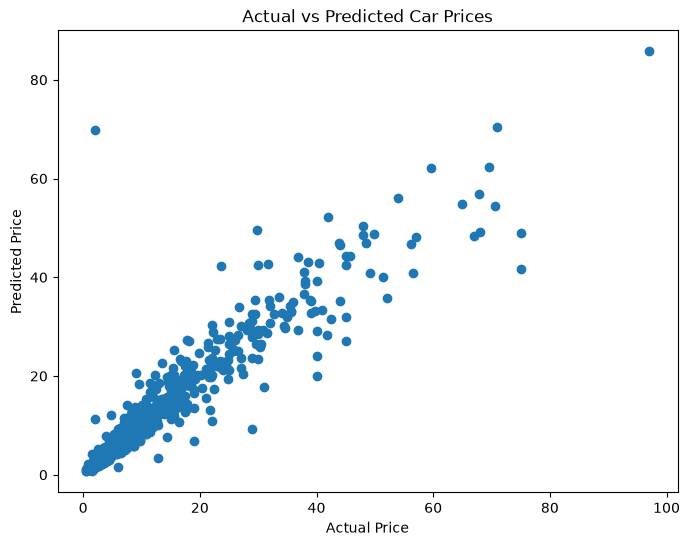

In [98]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [99]:
rf_model = pipeline.named_steps["model"]

In [100]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

In [101]:
importances = rf_model.feature_importances_

In [102]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

In [103]:
feature_importance_df.head(15)

,Feature,Importance
55,num__Power,0.656086
51,num__Year,0.153119
52,num__Kilometers_Driven,0.045502
54,num__Engine,0.037938
37,cat__Brand_Land,0.023983
53,num__Mileage,0.018621
5,cat__Location_Hyderabad,0.008270
56,num__Seats,0.008137
40,cat__Brand_Mercedes-Benz,0.005312
17,cat__Transmission_Manual,0.004790


In [104]:
import joblib

In [105]:
joblib.dump(pipeline,"car_price_model.pkl")

['car_price_model.pkl']

In [106]:
joblib.load("car_price_model.pkl")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['S.No.','Name','Location',...,'Power','Seats','Brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 